# Modélisation
## Import et chargement des données

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import cross_val_score

import optuna

# Regression Linéaire

In [2]:
data = pd.read_csv(r'../data/diamonds_cleaned.csv')
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53915,53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53916,53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53917,53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53918,53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


## Choix des features
Les variables `x, y et z` ont été écartées de la modélisation en raison de leur très forte corrélation avec `carat` et entre elles. Elles apportent donc une information en grande partie redondante. `carat` a été conservé comme indicateur principal de la taille du diamant.

In [3]:
data = data[['price','carat', 'cut', 'color', 'clarity', 'depth', 'table']]
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53920 entries, 0 to 53919
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    53920 non-null  int64  
 1   carat    53920 non-null  float64
 2   cut      53920 non-null  str    
 3   color    53920 non-null  str    
 4   clarity  53920 non-null  str    
 5   depth    53920 non-null  float64
 6   table    53920 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 2.9 MB


## Défintion de X et y

In [4]:
X = data.drop(columns='price')
y = data['price']

## Train/Test Split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=333
)

## scaling/ encodage 
Les variables numériques sont standardisées afin de les placer sur une échelle comparable et de faciliter l'entraînement des modèles sensibles à l'échelle des variables.

In [6]:
numeric_features = ['carat', 'depth', 'table']
categorical_features = ['cut', 'color', 'clarity']

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Entrainement du modèle 

In [8]:
model_lr = Pipeline([
    ('preprocessor', preprocess),
    ('regressor', LinearRegression())
])

In [9]:
model_lr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with

## Prédiction

In [10]:
y_pred_lr = model_lr.predict(x_test)

## Evaluation et Comparaison 
### Metrics

In [11]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R² : {r2_lr:.2f}")

MAE : 809.24
RMSE : 1169.17
R² : 0.92


### Résultats de la régression linéaire

La régression linéaire obtient un **MAE de 809,24 $, un RMSE de 1169,17 $ et un R² de 0,92**.

Ces résultats sont nettement meilleurs que ceux obtenus avec la baseline, qui avait un MAE de 2817,07 $, un RMSE de 4293,84 $ et un R² de -0,15.

Le modèle explique ainsi environ **92 % de la variabilité du prix** sur les données de test. L'erreur moyenne est également fortement réduite, passant d'environ 2817 $ avec la baseline à environ 809 $ avec la régression linéaire.

La régression linéaire constitue donc un premier modèle performant et montre que les caractéristiques sélectionnées permettent de prédire une grande partie du prix des diamants. Il sera toutefois intéressant de comparer ces performances à celles de modèles capables de capturer des relations non linéaires, comme les arbres de décision ou les Random Forest.


# Régression par arbre de décision 

In [12]:
model_dt = Pipeline([
    ('preprocess',preprocess),
    ('decision_tree',DecisionTreeRegressor(random_state=777))
])

In [13]:
model_dt.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('decision_tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wi

## Prédiction

In [14]:
y_pred_dt = model_dt.predict(x_test)

## Evaluation et Comparaison
### Metrics

In [15]:
mae_lr = mean_absolute_error(y_test, y_pred_dt)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_lr = r2_score(y_test, y_pred_dt)

print(f"MAE : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R² : {r2_lr:.2f}")

MAE : 350.76
RMSE : 707.15
R² : 0.97


### Interprétation des résultats

| Métrique | Linear Regression | Decision Tree |
| -------- | ----------------: | ------------: |
| MAE      |          809,24 $ |  **350,76 $** |
| RMSE     |         1169,17 $ |  **707,15 $** |
| R²       |              0,92 |      **0,97** |

Le Decision Tree améliore nettement les performances de la régression linéaire. L'erreur moyenne passe de **809,24 $ à 350,76 $**, tandis que le R² augmente de **0,92 à 0,97**. Le modèle explique donc environ **97 % de la variabilité du prix** sur le jeu de test.

Cette amélioration est cohérente avec les observations réalisées lors de l'EDA. La relation entre le `carat` et le `price` ne semble pas parfaitement linéaire : l'évolution du prix varie selon les différentes tailles de diamants. Une régression linéaire cherche à représenter cette relation par une tendance globale, tandis qu'un arbre de décision peut apprendre des relations plus complexes et non linéaires.

Le Decision Tree semble donc mieux adapté aux relations observées dans le dataset que la régression linéaire.

Mais un arbre seul peut surapprendre facilement. Le Random Forest va construire beaucoup d'arbres différents et combiner leurs prédictions.

# Random Forest Regressor
## Pipeline

In [16]:
model_rf = Pipeline([
    ('preprocess', preprocess),
    ('random_forest', RandomForestRegressor(random_state=777))
])

## Entrainement

In [17]:
model_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wi

## Prédiction

In [18]:
y_pred_rf = model_rf.predict(x_test)

## Metrics

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_rf)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_lr = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R² : {r2_lr:.2f}")

MAE : 281.08
RMSE : 538.27
R² : 0.98


### Interprétations et comparaison

Contrairement à un arbre de décision unique, le Random Forest combine les prédictions de plusieurs arbres afin d'obtenir un modèle plus robuste et de limiter le risque de surapprentissage.

Le modèle obtient les résultats suivants :

| Métrique | Linear Regression | Decision Tree | Random Forest |
| -------- | ----------------: | ------------: | ------------: |
| MAE      |          809,24 $ |      350,76 $ |  **281,08 $** |
| RMSE     |         1169,17 $ |      707,15 $ |  **538,27 $** |
| R²       |              0,92 |          0,97 |      **0,98** |

Le Random Forest améliore encore les performances obtenues avec le Decision Tree. Le **MAE passe de 350,76 $ à 281,08 $**, tandis que le **RMSE passe de 707,15 $ à 538,27 $**. Le R² atteint quant à lui **0,98**, ce qui signifie que le modèle explique environ **98 % de la variabilité du prix** sur les données de test.

Cette amélioration est cohérente avec le fonctionnement du Random Forest. Alors qu'un seul arbre peut être sensible aux particularités des données d'entraînement, le Random Forest combine plusieurs arbres et agrège leurs prédictions. Cela permet généralement d'obtenir des prédictions plus stables et plus robustes.

Les résultats confirment également les observations réalisées lors de l'EDA : les relations entre les caractéristiques des diamants et leur prix ne sont pas uniquement linéaires. Les modèles capables de capturer des relations non linéaires, comme le Decision Tree et le Random Forest, obtiennent ainsi de meilleures performances que la régression linéaire.

À ce stade, le **Random Forest est le meilleur modèle testé**, avec un MAE de 281,08 $ et un R² de 0,98. Il reste cependant à comparer ce résultat à d'autres modèles et à vérifier le risque de surapprentissage avant de procéder à une éventuelle optimisation des hyperparamètres.
# Gradient Boosting
## Pipeline

In [24]:
model_gb = Pipeline([
    ('preprocess', preprocess),
    ('gboost', GradientBoostingRegressor(random_state=777))
]
)

## Entrainement

In [25]:
model_gb.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('gboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

## Prediction

In [26]:
y_pred_gb = model_gb.predict(x_test)

## Evaluation et comparaison

In [27]:
mae_lr = mean_absolute_error(y_test, y_pred_gb)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_lr = r2_score(y_test, y_pred_gb)

print(f"MAE : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R² : {r2_lr:.2f}")

MAE : 405.44
RMSE : 730.56
R² : 0.97


### Interprétation et comparaison

Modèle d'ensemble basé sur la construction successive de plusieurs arbres de décision. Chaque nouvel arbre cherche à corriger les erreurs commises par les arbres précédents.

| Métrique | Linear Regression | Decision Tree | Random Forest | Gradient Boosting |
| -------- | ----------------: | ------------: | ------------: | ----------------: |
| MAE      |          809,24 $ |      350,76 $ |  **281,08 $** |          405,44 $ |
| RMSE     |         1169,17 $ |      707,15 $ |  **538,27 $** |          730,56 $ |
| R²       |              0,92 |          0,97 |      **0,98** |              0,97 |

Le Gradient Boosting obtient de bonnes performances, avec un **MAE de 405,44 $**, un **RMSE de 730,56 $** et un **R² de 0,97**. Il est donc nettement meilleur que la régression linéaire, mais ses performances restent légèrement inférieures à celles du Random Forest.

Ces résultats restent cohérents avec les observations réalisées lors de l'EDA. Comme le Decision Tree et le Random Forest, le Gradient Boosting est capable de prendre en compte des **relations non linéaires** entre les variables et des interactions entre celles-ci. Cela lui permet notamment de mieux modéliser l'évolution du prix selon le `carat` et les autres caractéristiques du diamant qu'une simple régression linéaire.

À ce stade, le **Random Forest reste le meilleur modèle testé**, avec le MAE et le RMSE les plus faibles ainsi que le meilleur R².

Le Gradient Boosting étant particulièrement sensible à ses hyperparamètres (`n_estimators`, `learning_rate`, `max_depth`, etc.), ses performances pourraient toutefois être améliorées grâce à une phase d'optimisation. Il sera donc intéressant de comparer l'optimisation du Random Forest et du Gradient Boosting avant de sélectionner le modèle final.

# Optimisation des hyperparamêtre
## Random Forest


In [ ]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', 1.0]
        )
    }

    model = Pipeline([
        ('preprocessor', preprocess),
        ('regressor', RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    return -scores.mean()

### Pourquoi `return -scores.mean()` ?

Nous utilisons `scoring='neg_mean_absolute_error'`. Scikit-learn retourne donc le **MAE sous forme négative**. Comme nous voulons que Optuna **minimise le MAE**, on inverse le signe. On récupère ainsi le **MAE réel et positif**, que Optuna cherche à minimiser.

In [35]:
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=15)

[I 2026-08-11 19:11:12,242] A new study created in memory with name: no-name-e020898f-0db6-4600-884c-3d6ba063dd72
[I 2026-08-11 19:12:07,580] Trial 0 finished with value: 294.4814963186687 and parameters: {'n_estimators': 202, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 1.0}. Best is trial 0 with value: 294.4814963186687.
[I 2026-08-11 19:13:18,726] Trial 1 finished with value: 292.4985732936807 and parameters: {'n_estimators': 135, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0}. Best is trial 1 with value: 292.4985732936807.
[I 2026-08-11 19:13:25,412] Trial 2 finished with value: 795.8465342277959 and parameters: {'n_estimators': 123, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 292.4985732936807.
[I 2026-08-11 19:13:40,215] Trial 3 finished with value: 449.8905380826484 and parameters: {'n_estimators': 163, 'max_depth': 19, 'min_samples_sp

In [36]:
print('Meilleur MAE:',study.best_value)
print('Meilleurs hyperparamêtres',study.best_params)

Meilleur MAE: 291.54860570150464
Meilleurs hyperparamêtres {'n_estimators': 100, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 1.0}


### Optimisation du Random Forest

L'optimisation des hyperparamètres du Random Forest a été réalisée avec **Optuna**, en utilisant une validation croisée sur le jeu d'entraînement. Le meilleur score obtenu est un **MAE de 291,55 $** en validation croisée.

Ce score permet d'identifier les meilleurs hyperparamètres sur le jeu d'entraînement, mais il ne peut pas être comparé directement au **MAE de 281,08 $ obtenu sur le jeu de test avec le Random Forest initial**, car ces deux performances sont calculées sur des jeux de données et selon des méthodes d'évaluation différentes.

Le modèle optimisé sera donc réentraîné avec les meilleurs hyperparamètres, puis évalué sur le **même jeu de test** que le modèle initial afin de comparer correctement leurs performances.

## Gradient Boosting

In [37]:
def objective_gb(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 50, 200, step=25
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.2
        ),
        'max_depth': trial.suggest_int(
            'max_depth', 2, 6
        ),
        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 8
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 1, 4
        ),
        'subsample': trial.suggest_float(
            'subsample', 0.7, 1.0
        )
    }

    model = Pipeline([
        ('preprocessor', preprocess),
        ('regressor', GradientBoostingRegressor(
            **params,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    return -scores.mean()

In [43]:
study_gb = optuna.create_study(direction='minimize')

study_gb.optimize(objective, n_trials=15)

[I 2026-08-11 19:45:28,049] A new study created in memory with name: no-name-600ddb5f-34fa-409a-b832-57c1462c1f48
[I 2026-08-11 19:45:44,201] Trial 0 finished with value: 530.6453572153888 and parameters: {'n_estimators': 149, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 530.6453572153888.
[I 2026-08-11 19:46:02,646] Trial 1 finished with value: 487.2882436638743 and parameters: {'n_estimators': 194, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 487.2882436638743.
[I 2026-08-11 19:47:29,261] Trial 2 finished with value: 290.78775848050464 and parameters: {'n_estimators': 246, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 1.0}. Best is trial 2 with value: 290.78775848050464.
[I 2026-08-11 19:47:46,268] Trial 3 finished with value: 474.3639851598109 and parameters: {'n_estimators': 175, 'max_depth': 30, 'min_samp

In [44]:
print("Meilleur MAE :", study_gb.best_value)
print("Meilleurs paramètres :", study_gb.best_params)

Meilleur MAE : 290.544620542239
Meilleurs paramètres : {'n_estimators': 225, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}


### Optimisation du Gradient Boosting

L'optimisation avec Optuna donne un **meilleur MAE de 290,88 $ en validation croisée**. Ce résultat servira à évaluer le Gradient Boosting optimisé sur le jeu de test afin de vérifier si l'optimisation apporte réellement une amélioration par rapport au modèle initial.

## Reentrainement des modèles optimisé
### Random Forest

In [45]:
best_rf = Pipeline([
    ('preprocess',preprocess),
    ('regressor',RandomForestRegressor(
        **study_gb.best_params,
        random_state=333
    ))
])

In [46]:
best_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with t

In [47]:
y_pred_rf = best_rf.predict(x_test)

In [49]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")

MAE : 278.28
RMSE : 530.11
R² : 0.98


### Évaluation du Random Forest optimisé

Après optimisation avec Optuna, le Random Forest obtient un **MAE de 278,28**, un **RMSE de 530,11** et un **R² de 0,98**. Les performances sont légèrement meilleures que celles du modèle initial (MAE : 281,08 $ ; RMSE : 538,27 $), mais le gain reste faible au regard du temps de calcul nécessaire à l'optimisation.

### Gradient Boosting

In [51]:
best_gb = Pipeline([
    ('preprocessor', preprocess),
    ('regressor', GradientBoostingRegressor(
        **study_gb.best_params,
        random_state=42
    ))
])

In [52]:
best_gb.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['carat','cut','color','clarity','depth','table']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with

In [53]:
y_pred_gb = best_gb.predict(x_test)

In [56]:
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")

MAE : 290.44
RMSE : 577.27
R² : 0.98


### Évaluation du Gradient Boosting optimisé

Après optimisation avec Optuna, le Gradient Boosting obtient un **MAE de 290,44 $**, un **RMSE de 577,27 $** et un **R² de 0,98**. Les performances sont nettement améliorées par rapport au modèle initial (MAE : 405,44 $ ; RMSE : 730,56 $), mais restent légèrement inférieures à celles du Random Forest optimisé.

## Conclusion Optimisation
* les modèles non linéaires sont beaucoup plus performants que la régression linéaire 
* le Random Forest est le meilleur modèle testé 
* Optuna a apporté une amélioration légère au Random Forest 
* le gain du tuning reste relativement faible par rapport au coût computationnel avec un MAE de 278 les prédictions sont en moyenne à environ 278 $ du prix réel.

# Analyse des erreurs du modèle
## Prix réel Vs Prix Prédit

In [57]:
results = pd.DataFrame({
    'prix_reel': y_test,
    'prix_predit': y_pred_rf
})

results['erreur'] = results['prix_reel'] - results['prix_predit']
results['erreur_absolue'] = results['erreur'].abs()

results.head()

,prix_reel,prix_predit,erreur,erreur_absolue
11879,5113,5066.016864,46.983136,46.983136
14533,5871,5771.741621,99.258379,99.258379
10805,4864,5289.740282,-425.740282,425.740282
28908,684,762.879930,-78.879930,78.879930
3397,567,500.655086,66.344914,66.344914


In [58]:
results.sort_values(
    'erreur_absolue',
    ascending=False
).head(10)

,prix_reel,prix_predit,erreur,erreur_absolue
21779,9856,16122.016236,-6266.016236,6266.016236
23797,11867,17094.571097,-5227.571097,5227.571097
22661,10716,15496.587208,-4780.587208,4780.587208
23089,11119,15833.834233,-4714.834233,4714.834233
21321,9475,14129.634178,-4654.634178,4654.634178
22973,11032,15645.066300,-4613.066300,4613.066300
24583,12907,17433.315984,-4526.315984,4526.315984
23880,11988,16444.773130,-4456.773130,4456.773130
23774,11843,15951.313154,-4108.313154,4108.313154
24482,12766,16834.733490,-4068.733490,4068.733490


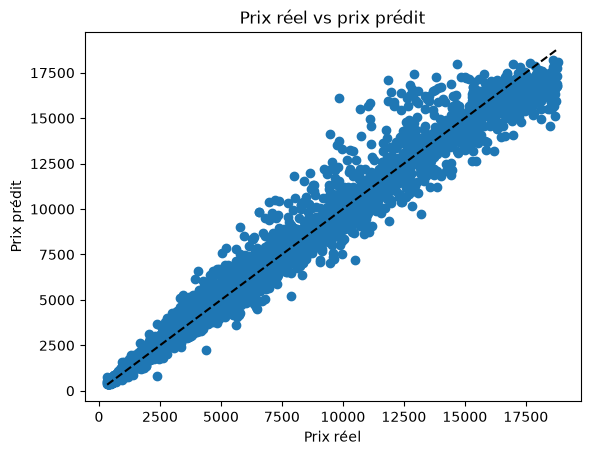

In [73]:
plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='black'
)

plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')
plt.title('Prix réel vs prix prédit')

plt.show()

### Observation

Le graphique montre une forte proximité entre les prix réels et les prix prédits, avec la majorité des points situés autour de la diagonale. Cela confirme les bonnes performances du modèle, avec peu d'écarts importants entre les prédictions et les valeurs réelles.

## Analyse des erreurs selon le carat

In [ ]:
errors = data.loc[y_test.index].copy()

errors['prix_predit'] = y_pred_rf
errors['erreur'] = errors['price'] - errors['prix_predit']
errors['erreur_absolue'] = errors['erreur'].abs()

errors.sort_values(
    'erreur_absolue',
    ascending=False
).head(10)

,price,carat,cut,color,clarity,depth,table,prix_predit,erreur,erreur_absolue
21779,9856,1.60,Ideal,G,VS1,62.0,57.0,16122.016236,-6266.016236,6266.016236
23797,11867,1.73,Premium,G,VS1,61.6,60.0,17094.571097,-5227.571097,5227.571097
22661,10716,2.38,Premium,J,SI2,60.6,59.0,15496.587208,-4780.587208,4780.587208
23089,11119,2.02,Premium,I,SI1,62.1,58.0,15833.834233,-4714.834233,4714.834233
21321,9475,2.00,Very Good,G,SI2,63.5,57.0,14129.634178,-4654.634178,4654.634178
22973,11032,1.71,Premium,G,VS2,61.3,58.0,15645.066300,-4613.066300,4613.066300
24583,12907,2.00,Ideal,I,VS1,62.3,56.0,17433.315984,-4526.315984,4526.315984
23880,11988,2.40,Ideal,I,SI2,62.8,57.0,16444.773130,-4456.773130,4456.773130
23774,11843,2.45,Very Good,J,SI2,60.6,63.0,15951.313154,-4108.313154,4108.313154
24482,12766,2.05,Premium,I,VS1,60.3,59.0,16834.733490,-4068.733490,4068.733490


In [67]:
errors[errors['carat'] > 0.70]

,price,carat,cut,color,clarity,depth,table,prix_predit,erreur,erreur_absolue
11879,5113,1.06,Premium,G,SI1,62.2,57.0,5066.016864,46.983136,46.983136
14533,5871,1.68,Good,E,I1,64.3,60.0,5771.741621,99.258379,99.258379
10805,4864,1.00,Very Good,E,SI1,62.1,57.0,5289.740282,-425.740282,425.740282
27609,18524,2.00,Very Good,G,SI1,61.8,61.0,17539.501128,984.498872,984.498872
24760,13134,2.00,Premium,H,SI2,61.5,61.0,13041.302002,92.697998,92.697998
...,...,...,...,...,...,...,...,...,...,...
4338,3601,0.81,Ideal,E,VS2,62.0,55.0,3838.555795,-237.555795,237.555795
10977,4911,1.15,Ideal,H,SI1,63.0,57.0,5415.683097,-504.683097,504.683097
3475,3394,1.01,Premium,H,SI2,60.9,59.0,3955.569057,-561.569057,561.569057
26528,16215,1.60,Premium,G,VVS2,60.6,60.0,16018.619916,196.380084,196.380084


In [68]:
errors.shape

(10784, 10)

In [69]:
errors.groupby(
    pd.cut(errors['carat'], bins=[0, 0.5, 1, 1.5, 2, 3, errors['carat'].max()])
)['erreur_absolue'].mean()

carat
(0.0, 0.5]       79.788250
(0.5, 1.0]      180.499806
(1.0, 1.5]      417.548896
(1.5, 2.0]      781.059520
(2.0, 3.0]     1292.450319
(3.0, 4.01]    1211.602716
Name: erreur_absolue, dtype: float64

In [70]:
errors['erreur_relative'] = (
    errors['erreur_absolue'] / errors['price'] * 100
)

errors.groupby(
    pd.cut(errors['carat'], bins=[0, 0.5, 1, 1.5, 2, 3, errors['carat'].max()])
)['erreur_relative'].mean()

carat
(0.0, 0.5]     9.994690
(0.5, 1.0]     6.512803
(1.0, 1.5]     6.895774
(1.5, 2.0]     7.383341
(2.0, 3.0]     9.090006
(3.0, 4.01]    7.303289
Name: erreur_relative, dtype: float64

### Observation

L'erreur absolue augmente nettement avec le `carat`, passant d'environ 80 dollars pour les diamants de moins de 0,5 carat à plus de 1 200 $ pour les diamants de plus de 2 carats. Cependant, en termes relatifs, l'erreur reste relativement stable, autour de **6 à 10 % du prix**. Les erreurs plus importantes observées sur les gros diamants semblent donc principalement liées à leur prix plus élevé plutôt qu'à une réelle perte de précision du modèle.


# Conclusion modélisation
| Modèle                     |    MAE ($) |   RMSE ($) |       R² |
| -------------------------- | ---------: | ---------: | -------: |
| Linear Regression          |     809,24 |   1 169,17 |     0,92 |
| Decision Tree              |     350,76 |     707,15 |     0,97 |
| Random Forest              |     281,08 |     538,27 |     0,98 |
| Gradient Boosting          |     405,44 |     730,56 |     0,97 |
| **Random Forest optimisé** | **278,28** | **530,11** | **0,98** |
| Gradient Boosting optimisé |     290,44 |     577,27 |     0,98 |


Ce projet avait pour objectif de prédire le prix d'un diamant à partir de ses caractéristiques physiques et de ses critères de qualité. Après l'analyse exploratoire, plusieurs modèles ont été testés et comparés.

La **Random Forest optimisée** obtient les meilleures performances avec un **MAE de 278,28**, un **RMSE de 530,11** et un **R² de 0,98**. L'analyse des erreurs montre que l'erreur absolue augmente avec le carat, mais que l'erreur relative reste globalement stable, autour de 6 à 10 % du prix.

L'optimisation avec Optuna a permis d'améliorer légèrement les performances du Random Forest, mais au prix d'un temps de calcul important. Le modèle final permet donc d'obtenir des prédictions fiables tout en montrant que les caractéristiques des diamants permettent d'expliquer une grande partie de la variation de leur prix.
